[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A2_experiments_ab_testing.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's second appendix (see `README.md`), written like the module's core notebooks: same rhythm, same ✋/🧪/🧠 ladder. It runs on the core course stack (`numpy`, `scipy`, `pandas`, `matplotlib`) with all data generated inline — 100 % offline.

---
# 📓 Notebook A2 (IA) — Experiment Design & A/B Testing for Business Decisions

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

Four notebooks in this module end with some version of the same sentence. NB 23: *"a randomized holdout in every campaign is how you graduate to uplift."* NB 24: *"the selective-labels problem."* A1 §5: *"the deliverable for the monitor is **an experiment**, not a price."* Each time we pointed at a test and moved on.

This notebook is that test. And it is not a formality — **most A/B tests run in industry cannot answer the question they were built to answer**, for reasons that are all knowable *before* the test starts.

> 🧠 **Mental model.** An experiment is not a truth machine, it is a **measuring instrument with a resolution**. A ruler marked in centimetres cannot measure the thickness of a sheet of paper, and no amount of squinting will fix that. Before you run a test, work out its resolution — the smallest effect it could reliably see — and compare that with the smallest effect you would *act on*. If the resolution is coarser than the decision, the test is already finished: it will return "no significant difference," you will believe the change does nothing, and you will be wrong.

Everything else in this notebook — peeking, variance reduction, the winner's curse — is a consequence of that one idea.

## 🎯 Learning objectives

By the end you can:

1. Compute an experiment's **minimum detectable effect (MDE)** for a proportion and a mean, and use it to decide whether a test is worth running *at all*.
2. Explain and demonstrate why **"not significant" is not "no effect"**, and quantify the false-negative rate of an underpowered test by simulation.
3. Use **CUPED** (pre-period covariate adjustment) to cut variance, and predict the gain from the pre/post correlation alone.
4. Show what **peeking** does to a 5 % test, and calibrate an honest early-stopping boundary by simulation.
5. Run the **validity checks** that come before interpretation — sample-ratio mismatch and the multiple-comparisons tax.
6. Turn a result into a **decision**: the winner's curse, why low power corrupts the effect sizes you *do* find, and the expected-value frame for shipping.

## ✅ Prerequisites

**NB 10** (confidence intervals, t-tests, effect sizes) is the hard dependency — this notebook is NB 10 pointed at a business decision. **NB 18** for the threshold/decision mindset, and **A1** if you want §7's price-test design to land. All data is generated inline; everything runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
ALPHA, POWER = 0.05, 0.80
Z_A = stats.norm.ppf(1 - ALPHA / 2)      # 1.960 -- two-sided
Z_B = stats.norm.ppf(POWER)              # 0.842
print(f"z(alpha/2) = {Z_A:.3f}   z(power) = {Z_B:.3f}   sum = {Z_A + Z_B:.3f}")

z(alpha/2) = 1.960   z(power) = 0.842   sum = 2.802


## 1. Three decisions waiting on evidence

Back at the **B2B webshop** (NB 25, A1). Three teams each want to change something, and each has been told to "test it first":

| # | Change | Metric | Unit of randomization | Population available |
|---|---|---|---|---|
| **D1** | Redesigned checkout | conversion rate (3.2 % today) | session | ~2,500 sessions/week |
| **D2** | "Spend €500/quarter, get free next-day delivery for a year" loyalty offer | revenue per customer over 8 weeks | customer | 1,200 B2B customers |
| **D3** | The monitor price rise from **A1 §5** | units & margin | region | 12 regions |

Notice how the population shrinks as the decision gets more valuable. That is the usual shape of things: the cheap-to-test changes are the ones that matter least. D1 has plenty of traffic but a tiny effect to find; D2 has a big effect but few units; D3 has almost no units at all.

The first job — before writing a line of analysis code — is to work out which of these tests can actually work.

## 2. Before you run it: the MDE, and the test you should cancel

For a two-sample comparison at significance α and power 1−β, the sample size per arm needed to detect a true difference Δ is

$$n = \frac{2\sigma^{2}\,(z_{\alpha/2} + z_{\beta})^{2}}{\Delta^{2}}$$

Turn it inside out and you get the number that actually drives decisions — the **minimum detectable effect**:

$$\text{MDE} = (z_{\alpha/2} + z_{\beta})\,\sigma\sqrt{\frac{2}{n}}$$

Three things to read off that formula before touching any data:

- **MDE shrinks with √n.** Four times the traffic buys you *half* the resolution. This is why "just run it a bit longer" so rarely rescues a test.
- **MDE scales with σ.** Halving the noise is worth quadrupling the sample — which is the entire argument for §4.
- **For a proportion, σ² = p(1−p)** and you get it for free from the baseline rate. No pilot needed.

In [2]:
def mde_prop(p, n_per_arm, alpha=ALPHA, power=POWER):
    """Smallest detectable absolute difference in a conversion rate."""
    z = stats.norm.ppf(1 - alpha / 2) + stats.norm.ppf(power)
    return z * np.sqrt(2 * p * (1 - p) / n_per_arm)

def n_prop(p, delta, alpha=ALPHA, power=POWER):
    """Sessions per arm needed to detect an absolute difference `delta`."""
    z = stats.norm.ppf(1 - alpha / 2) + stats.norm.ppf(power)
    return 2 * p * (1 - p) * z ** 2 / delta ** 2

BASE_CVR, SESSIONS_WK = 0.032, 2500
print("D1 -- checkout redesign, 2,500 sessions/week split 50/50")
print(f"{'weeks':>6} {'n/arm':>8} {'MDE (pp)':>10} {'MDE (relative)':>16}")
for w in (2, 4, 8, 12, 26):
    n = SESSIONS_WK / 2 * w
    m = mde_prop(BASE_CVR, n)
    print(f"{w:>6} {n:>8,.0f} {m * 100:>10.2f} {m / BASE_CVR:>15.1%}")

D1 -- checkout redesign, 2,500 sessions/week split 50/50
 weeks    n/arm   MDE (pp)   MDE (relative)
     2    2,500       1.39           43.6%
     4    5,000       0.99           30.8%
     8   10,000       0.70           21.8%
    12   15,000       0.57           17.8%
    26   32,500       0.39           12.1%


In [3]:
# The team's hypothesis: the redesign is worth "about half a point" of conversion.
for target_pp in (1.0, 0.5, 0.32):
    d = target_pp / 100
    n = n_prop(BASE_CVR, d)
    print(f"to detect {target_pp:>4.2f} pp ({d / BASE_CVR:>4.0%} relative): "
          f"{n:>9,.0f} sessions/arm -> {n * 2 / SESSIONS_WK:>5.1f} weeks")

to detect 1.00 pp ( 31% relative):     4,863 sessions/arm ->   3.9 weeks
to detect 0.50 pp ( 16% relative):    19,450 sessions/arm ->  15.6 weeks
to detect 0.32 pp ( 10% relative):    47,486 sessions/arm ->  38.0 weeks


**D1 is already over.** The team believes the redesign is worth about **+0.5 pp**. At this traffic that needs **~19,450 sessions per arm — 15.6 weeks**, and nobody is holding a checkout redesign in a feature flag for four months. Run the 4-week test everyone has budgeted for and its resolution is **±0.99 pp**: it can only detect an effect twice as large as the one anyone expects.

So the 4-week test has a *knowable* outcome before it starts: "no significant difference." The team will conclude the redesign doesn't work.

This is the single highest-value calculation in the notebook, and it takes one line. The honest options when the MDE is coarser than the decision:

1. **Don't run it.** Ship on judgement (it's a redesign, the downside is bounded) and monitor. A test that cannot resolve the decision is worse than no test, because it produces a *false* answer with a p-value attached.
2. **Change the metric** to something higher up the funnel with a bigger base rate — add-to-cart instead of purchase. More power, but you're now measuring a **proxy**, and proxies move without the goal moving.
3. **Change the unit** — randomize customers rather than sessions and use a metric with a pre-period, which unlocks §4's variance reduction.
4. **Raise the bar for action**, honestly: "we will ship only if it moves conversion by more than a point." Then the 4-week test *is* adequate — for that decision.

D2 takes option 3, and the rest of the notebook follows it.

---

### ✋ Quick exercise (~2 min) — would a proxy metric rescue D1?

Option 2 above: measure **add-to-cart** rate instead of purchase conversion. Today's add-to-cart rate is **11.0 %**.

At 2,500 sessions/week over 4 weeks, what is the MDE on add-to-cart in percentage points, and as a *relative* change? Compare it with the 30.8 % relative MDE on purchase conversion. Does the higher base rate help in relative terms?

```python
n_arm = SESSIONS_WK / 2 * 4
```

In [4]:
# ✍️ Your turn 👇
n_arm = SESSIONS_WK / 2 * 4
# MDE on add-to-cart (base 11%) in pp and relative; compare with purchase conversion:

<details>
<summary>✅ <b>Solution</b></summary>

```python
n_arm = SESSIONS_WK / 2 * 4
for label, p in [("purchase", BASE_CVR), ("add-to-cart", 0.11)]:
    m = mde_prop(p, n_arm)
    print(f"{label:12s} base {p:>6.1%}  MDE {m * 100:>5.2f} pp  ({m / p:>5.1%} relative)")
```

Add-to-cart's MDE is **larger in absolute terms** (≈1.75 pp vs 0.99 pp) but **much smaller in relative terms** (≈16 % vs 31 %). That is the whole reason to move up the funnel: σ² = p(1−p) grows like p, but the *baseline you divide by* grows like p, so relative resolution improves roughly as 1/√p.

The catch is not statistical. A 16 % relative resolution on add-to-cart is only useful if a 16 % add-to-cart move implies a purchase move you care about — and checkout redesigns are exactly the change that can lift add-to-cart while *hurting* purchases. You have bought power by measuring something you don't want to maximise. Proxy metrics are a real tool; just never let the proxy quietly become the goal.
</details>

## 3. D2: the loyalty offer, and a test that says nothing

D2 is the promising one: **1,200 B2B customers**, randomized 50/50, revenue per customer measured over 8 weeks. Because these are existing customers we also have their revenue for the **8 weeks before** the test — remember that, it becomes the hero of §4.

The generator below plants a **true +9 % lift**. We know it; the analyst doesn't.

In [5]:
N = 1200
TRUE_LIFT = 0.09
MU_LOG, SIG_LOG, RHO_LOG = 6.5058, 0.7703, 0.87   # heavy-tailed, sticky B2B spend
HALF = N // 2

def simulate_trial(seed, lift=TRUE_LIFT, n=N):
    """One experiment: pre-period revenue, post-period revenue, and the assignment."""
    r = np.random.default_rng(seed)
    log_pre = r.normal(MU_LOG, SIG_LOG, n)
    shock = r.normal(0, 1, n)
    log_post = (MU_LOG + RHO_LOG * (log_pre - MU_LOG)
                + np.sqrt(1 - RHO_LOG ** 2) * SIG_LOG * shock)
    pre, post = np.exp(log_pre), np.exp(log_post)
    treated = np.zeros(n, dtype=bool)
    treated[n // 2:] = True                       # balanced by construction
    return pre, post * (1 + lift * treated), treated

pre, post, treated = simulate_trial(seed=0)
trial = pd.DataFrame({"pre_revenue": pre.round(2), "post_revenue": post.round(2),
                      "arm": np.where(treated, "offer", "control")})
print(trial.groupby("arm").agg(n=("post_revenue", "size"),
                               pre_mean=("pre_revenue", "mean"),
                               post_mean=("post_revenue", "mean"),
                               post_sd=("post_revenue", "std")).round(1).to_string())
print(f"\npre/post correlation: {np.corrcoef(pre, post)[0, 1]:.3f}   "
      f"coefficient of variation: {post.std(ddof=1) / post.mean():.2f}")
print(f"pre-period imbalance between arms (pure chance): "
      f"{pre[treated].mean() / pre[~treated].mean() - 1:+.1%}")

           n  pre_mean  post_mean  post_sd
arm                                       
control  600     875.9      874.1    762.3
offer    600     851.9      922.2    743.1

pre/post correlation: 0.816   coefficient of variation: 0.84
pre-period imbalance between arms (pure chance): -2.7%


Two things to notice before any test is run. The coefficient of variation is **0.84** — B2B spend is wildly unequal, a handful of accounts dominate, and that variance is what we will be fighting all notebook. And the two arms already differ by **−2.7 %** in the *pre-period*, before the offer existed: randomization guarantees balance in expectation, not in any particular sample. That chance imbalance is pure noise sitting on top of the effect we want to measure — and §4 is about removing it.

In [6]:
def welch(y, treated):
    """Welch t-test plus the numbers a decision needs: lift and its CI."""
    a, b = y[treated], y[~treated]
    diff = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1) / a.size + b.var(ddof=1) / b.size)
    df = se ** 4 / ((a.var(ddof=1) / a.size) ** 2 / (a.size - 1)
                    + (b.var(ddof=1) / b.size) ** 2 / (b.size - 1))
    t = diff / se
    p = 2 * stats.t.sf(abs(t), df)
    crit = stats.t.ppf(0.975, df)
    return dict(diff=diff, se=se, p=p, rel=diff / b.mean(),
                lo=(diff - crit * se) / b.mean(), hi=(diff + crit * se) / b.mean())

raw = welch(post, treated)
print(f"observed lift  {raw['diff']:+8.2f} EUR/customer  ({raw['rel']:+.2%})")
print(f"95% CI         [{raw['lo']:+.2%}, {raw['hi']:+.2%}]")
print(f"p-value        {raw['p']:.3f}   ->  "
      f"{'REJECT the null' if raw['p'] < 0.05 else 'NOT significant'}")
print(f"\nMDE for this design: "
      f"{(Z_A + Z_B) * post.std(ddof=1) * np.sqrt(2 / HALF) / post.mean():.1%} relative")

observed lift    +48.05 EUR/customer  (+5.50%)
95% CI         [-4.26%, +15.25%]
p-value        0.269   ->  NOT significant

MDE for this design: 13.6% relative


The analyst's report writes itself: *"The loyalty offer produced a +5.5 % revenue change, which was not statistically significant (p = 0.27). We recommend not rolling it out."*

Every number in that sentence is correctly computed. The conclusion is wrong — the offer really does lift revenue 9 %. The test's resolution was **≈13.6 %**, and it was asked to find 9 %.

> 🚫 **Misconception — "The test wasn't significant, so the change doesn't work."**
> A p-value above 0.05 means *"this data is consistent with no effect."* It does **not** mean *"there is no effect"* — data from an underpowered test is consistent with no effect, with a small effect, and often with a large one, all at once. Look at the confidence interval, not the p-value: this one spans **−4.3 % to +15.3 %**, so the honest report is **"we learned nothing"**, not "it doesn't work". Those two conclusions lead to opposite decisions and only one of them is true.

### 🔬 What actually happens: power, by brute force

The formula says this design has low power. Rather than trust it, let's *measure* it: run the same experiment 4,000 times with the same true +9 % lift and count how often it comes back significant. That fraction **is** the power, by definition — and 1 − power is the rate at which a real, valuable, 9 % effect gets thrown away.

The vectorised generator below runs all 4,000 experiments at once (one row per experiment) — the same maths as `simulate_trial`, reshaped so the notebook stays fast.

In [7]:
def simulate_many(n_sims, lift, seed):
    """(n_sims, N) matrices of pre/post revenue -- one experiment per row."""
    r = np.random.default_rng(seed)
    log_pre = r.normal(MU_LOG, SIG_LOG, (n_sims, N))
    shock = r.normal(0, 1, (n_sims, N))
    log_post = (MU_LOG + RHO_LOG * (log_pre - MU_LOG)
                + np.sqrt(1 - RHO_LOG ** 2) * SIG_LOG * shock)
    treated = np.zeros(N, dtype=bool); treated[N // 2:] = True
    return np.exp(log_pre), np.exp(log_post) * (1 + lift * treated), treated

def welch_rows(y, treated):
    """Row-wise Welch test. Returns (relative lift, p-value) per experiment."""
    a, b = y[:, treated], y[:, ~treated]
    na, nb = a.shape[1], b.shape[1]
    va, vb = a.var(1, ddof=1), b.var(1, ddof=1)
    diff = a.mean(1) - b.mean(1)
    se = np.sqrt(va / na + vb / nb)
    df = se ** 4 / ((va / na) ** 2 / (na - 1) + (vb / nb) ** 2 / (nb - 1))
    return diff / b.mean(1), 2 * stats.t.sf(np.abs(diff / se), df)

SIMS = 4000
pre_s, post_s, tr_s = simulate_many(SIMS, TRUE_LIFT, seed=1)
rel_s, p_s = welch_rows(post_s, tr_s)
pre_0, post_0, _ = simulate_many(SIMS, 0.0, seed=2)
_, p_0 = welch_rows(post_0, tr_s)

print(f"true lift +{TRUE_LIFT:.0%}, {SIMS} simulated experiments")
print(f"  power (share significant)        {(p_s < 0.05).mean():.1%}")
print(f"  FALSE NEGATIVES (real effect, called 'no effect')  {(p_s >= 0.05).mean():.1%}")
print(f"  false-positive rate under the null (sanity check)  {(p_0 < 0.05).mean():.1%}")

true lift +9%, 4000 simulated experiments
  power (share significant)        38.5%
  FALSE NEGATIVES (real effect, called 'no effect')  61.6%
  false-positive rate under the null (sanity check)  5.1%


**The design throws away a real 9 % revenue lift about three times in five.** That is not a subtle statistical caveat; it is a business process that discards good ideas at a rate no one has ever put in a slide. And the false-positive check lands on ~5 %, exactly as advertised — the machinery is working correctly. The problem is the resolution, not the maths.

> ⚠️ **The asymmetry nobody budgets for.** Teams agonise over α (the 5 %) and ignore β (here, ~60 %). Both are business costs: α is the cost of shipping something worthless, β the cost of killing something valuable. A company that runs dozens of underpowered tests a year is running a machine that systematically prefers the status quo — and it will never see the bodies, because a false negative looks exactly like a correct negative.

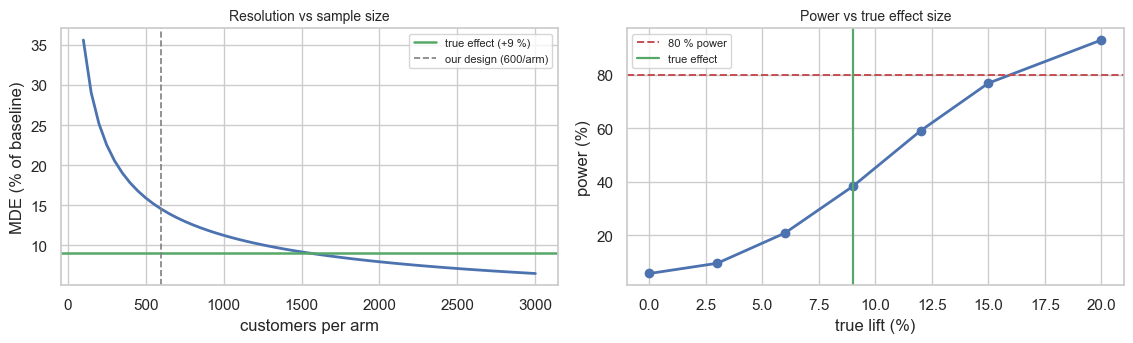

power by true lift: {'0%': '6%', '3%': '9%', '6%': '21%', '9%': '38%', '12%': '59%', '15%': '77%', '20%': '93%'}


In [8]:
ns = np.arange(100, 3001, 50)
sd_ratio = post_s.std(1, ddof=1).mean() / post_s.mean(1).mean()      # relative sigma
mde_rel = (Z_A + Z_B) * sd_ratio * np.sqrt(2 / ns)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
axes[0].plot(ns, mde_rel * 100, lw=2, color="#4c72b0")
axes[0].axhline(TRUE_LIFT * 100, color="#55a868", lw=1.8, ls="-", label="true effect (+9 %)")
axes[0].axvline(HALF, color="grey", ls="--", lw=1.2, label=f"our design ({HALF}/arm)")
axes[0].set_xlabel("customers per arm"); axes[0].set_ylabel("MDE (% of baseline)")
axes[0].set_title("Resolution vs sample size", fontsize=10)
axes[0].legend(fontsize=8)

# empirical power curve across a range of true lifts
lifts = np.array([0.0, 0.03, 0.06, 0.09, 0.12, 0.15, 0.20])
pw = [ (welch_rows(simulate_many(1200, L, seed=7 + i)[1], tr_s)[1] < 0.05).mean()
       for i, L in enumerate(lifts) ]
axes[1].plot(lifts * 100, np.array(pw) * 100, "o-", lw=2, color="#4c72b0")
axes[1].axhline(80, color="#c44e52", ls="--", lw=1.4, label="80 % power")
axes[1].axvline(TRUE_LIFT * 100, color="#55a868", lw=1.6, label="true effect")
axes[1].set_xlabel("true lift (%)"); axes[1].set_ylabel("power (%)")
axes[1].set_title("Power vs true effect size", fontsize=10); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("power by true lift:",
      {f"{L:.0%}": f"{p:.0%}" for L, p in zip(lifts, pw)})

## 4. CUPED: the cheapest power you will ever buy

Look again at the MDE formula: `MDE ∝ σ√(2/n)`. Getting more customers is slow and expensive. **Reducing σ is free** — if you have a variable measured *before* randomization that predicts the outcome.

Our customers' pre-period revenue is such a variable, and it is a very good one: B2B spend is sticky, so pre and post revenue correlate around 0.8. The trick, known in the experimentation literature as **CUPED** (Controlled-experiment Using Pre-Experiment Data), is to analyse an adjusted outcome:

$$Y^{\text{adj}}_i = Y_i - \theta\,(X_i - \bar{X}), \qquad \theta = \frac{\text{Cov}(Y, X)}{\text{Var}(X)}$$

Two properties make this safe rather than clever:

- **It cannot bias the treatment effect.** *X* is measured before assignment, so its mean is the same in both arms up to chance; subtracting a multiple of it shifts both arms equally. You are removing variation that has nothing to do with the treatment.
- **The variance reduction is exactly ρ².** Choose θ optimally and `Var(Y_adj) = Var(Y)(1 − ρ²)`, so the MDE shrinks by √(1 − ρ²). At ρ = 0.8 that is a **40 % smaller MDE** — the same as running the test almost **three times** as long.

The one rule: θ and *X* must come from **before** the treatment could possibly have acted. A "pre-period" that overlaps the test is just leakage wearing a lab coat (NB 23's post-outcome leakage, A1's display effect — the same family).

In [9]:
def cuped(pre, post):
    """Return the variance-reduced outcome and the theta used."""
    theta = np.cov(post, pre, ddof=1)[0, 1] / np.var(pre, ddof=1)
    return post - theta * (pre - pre.mean()), theta

adj, theta = cuped(pre, post)
rho = np.corrcoef(pre, post)[0, 1]
print(f"theta {theta:.3f} | rho {rho:.3f} | rho^2 {rho ** 2:.3f}")
print(f"sd  {post.std(ddof=1):7.1f}  ->  {adj.std(ddof=1):7.1f}   "
      f"({adj.std(ddof=1) / post.std(ddof=1) - 1:+.1%})")
print(f"variance reduction  observed {1 - adj.var(ddof=1) / post.var(ddof=1):.1%}  "
      f"vs theory (rho^2) {rho ** 2:.1%}")
print(f"\nmeans are untouched by construction: "
      f"post {post.mean():.2f} -> adj {adj.mean():.2f}")

theta 0.831 | rho 0.816 | rho^2 0.665
sd    752.8  ->    435.4   (-42.2%)
variance reduction  observed 66.5%  vs theory (rho^2) 66.5%

means are untouched by construction: post 898.14 -> adj 898.14


In [10]:
cup = welch(adj, treated)
print(f"{'':14s} {'lift':>9} {'95% CI':>20} {'p':>8}   verdict")
for name, r in (("raw", raw), ("CUPED", cup)):
    ci = f"[{r['lo']:+.1%}, {r['hi']:+.1%}]"
    print(f"{name:14s} {r['rel']:>+8.2%} {ci:>20} {r['p']:>8.3f}   "
          f"{'SIGNIFICANT' if r['p'] < 0.05 else 'not significant'}")
print(f"\nCI width: raw {raw['hi'] - raw['lo']:.1%}  ->  CUPED {cup['hi'] - cup['lo']:.1%}")
print(f"true lift {TRUE_LIFT:+.0%}")

                    lift               95% CI        p   verdict
raw              +5.50%      [-4.3%, +15.3%]    0.269   not significant
CUPED            +7.87%      [+2.2%, +13.6%]    0.007   SIGNIFICANT

CI width: raw 19.5%  ->  CUPED 11.4%
true lift +9%


**Same customers. Same eight weeks. Same data.** One line of arithmetic moved the experiment from "not significant, don't roll it out" to a significant result whose confidence interval contains the truth. Nothing was p-hacked: the adjustment was specified before the analysis, uses only pre-treatment information, and leaves the estimand unchanged.

It is worth being precise about what improved. The **point estimate barely moved** — it was never biased. What shrank is the *uncertainty*: the CI narrowed from 19.5 points to 11.4. CUPED does not find effects, it stops noise from hiding them.

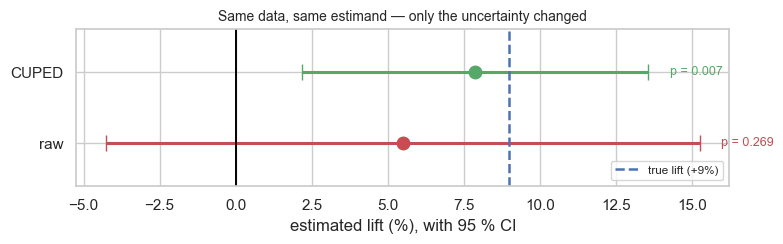

In [11]:
fig, ax = plt.subplots(figsize=(8, 2.6))
for i, (name, r) in enumerate([("raw", raw), ("CUPED", cup)]):
    colour = "#c44e52" if r["p"] >= 0.05 else "#55a868"
    ax.errorbar(r["rel"] * 100, i, xerr=[[(r["rel"] - r["lo"]) * 100],
                                         [(r["hi"] - r["rel"]) * 100]],
                fmt="o", ms=9, capsize=6, lw=2.2, color=colour)
    ax.text(r["hi"] * 100 + 0.7, i, f"p = {r['p']:.3f}", va="center", fontsize=9,
            color=colour)
ax.axvline(0, color="black", lw=1.4)
ax.axvline(TRUE_LIFT * 100, color="#4c72b0", lw=1.8, ls="--",
           label=f"true lift (+{TRUE_LIFT:.0%})")
ax.set_yticks([0, 1]); ax.set_yticklabels(["raw", "CUPED"])
ax.set_ylim(-0.6, 1.6); ax.set_xlabel("estimated lift (%), with 95 % CI")
ax.set_title("Same data, same estimand — only the uncertainty changed", fontsize=10)
ax.legend(fontsize=8.5, loc="lower right"); plt.tight_layout(); plt.show()

Both intervals contain the truth; both point estimates are honest. The only difference is that one of them is narrow enough to **act on**, and the raw interval's overlap with zero is what would have killed the offer. Note also that the raw interval reaches further *up* than CUPED's — an underpowered test is not just uninformative about whether an effect exists, it is uninformative about how big it is, in both directions. §7 is where that becomes expensive.

In [12]:
# Row-wise CUPED across all 4,000 simulated experiments at once.
pm = pre_s.mean(1, keepdims=True); om = post_s.mean(1, keepdims=True)
th = (((pre_s - pm) * (post_s - om)).sum(1, keepdims=True)
      / ((pre_s - pm) ** 2).sum(1, keepdims=True))
adj_s = post_s - th * (pre_s - pm)
_, p_s_c = welch_rows(adj_s, tr_s)

pm0 = pre_0.mean(1, keepdims=True); om0 = post_0.mean(1, keepdims=True)
th0 = (((pre_0 - pm0) * (post_0 - om0)).sum(1, keepdims=True)
       / ((pre_0 - pm0) ** 2).sum(1, keepdims=True))
_, p_0_c = welch_rows(post_0 - th0 * (pre_0 - pm0), tr_s)

print(f"{'analysis':>10} {'power @ +9%':>12} {'false-neg':>11} {'FP @ null':>11}")
for name, ps, p0 in (("raw", p_s, p_0), ("CUPED", p_s_c, p_0_c)):
    print(f"{name:>10} {(ps < 0.05).mean():>12.1%} {(ps >= 0.05).mean():>11.1%} "
          f"{(p0 < 0.05).mean():>11.1%}")
print("\nEquivalent extra sample the raw analysis would have needed: "
      f"{(1 / (1 - rho ** 2) - 1):.1%} more customers, i.e. "
      f"{HALF * (1 / (1 - rho ** 2)):.0f}/arm instead of {HALF}")

  analysis  power @ +9%   false-neg   FP @ null
       raw        38.5%       61.6%        5.1%
     CUPED        85.7%       14.3%        5.3%

Equivalent extra sample the raw analysis would have needed: 198.9% more customers, i.e. 1793/arm instead of 600


Power **more than doubles**, the false-negative rate collapses, and the false-positive rate stays at 5 % — the correction is free, not a trade.

> ⚠️ **Two honest caveats.** θ is *estimated*, so at very small n the false-positive rate can drift a little above α (visible here only within Monte-Carlo noise; with 4,000 sims the standard error on a 5 % rate is ±0.3 pp). And CUPED buys you nothing when ρ ≈ 0 — new users have no pre-period, which is precisely why acquisition experiments are so much harder than retention experiments. Check ρ before promising anyone a faster test.

---

### ✋ Quick exercise (~2 min) — how much correlation do you need?

You want CUPED to **halve** your MDE. Since `MDE ∝ σ√(1 − ρ²)`, what pre/post correlation ρ does that require? Then tabulate the MDE reduction and the "equivalent sample multiplier" `1/(1 − ρ²)` for ρ = 0.3, 0.5, 0.7, 0.8, 0.9.

```python
rhos = np.array([0.3, 0.5, 0.7, 0.8, 0.9])
```

In [13]:
# ✍️ Your turn 👇
rhos = np.array([0.3, 0.5, 0.7, 0.8, 0.9])
# MDE multiplier sqrt(1 - rho^2), and the equivalent sample multiplier 1/(1 - rho^2):

<details>
<summary>✅ <b>Solution</b></summary>

```python
rhos = np.array([0.3, 0.5, 0.7, 0.8, 0.9])
print(f"{'rho':>5} {'var reduction':>14} {'MDE multiplier':>15} {'equivalent n multiplier':>24}")
for r in rhos:
    print(f"{r:>5.1f} {r**2:>14.0%} {np.sqrt(1 - r**2):>15.3f} {1 / (1 - r**2):>24.2f}x")
print(f"\nto halve the MDE you need sqrt(1 - rho^2) = 0.5 -> rho = {np.sqrt(1 - 0.25):.3f}")
```

You need **ρ ≈ 0.866** to halve the MDE — a high bar, met by sticky metrics (subscription revenue, repeat B2B orders) and missed by volatile ones.

The equivalent-sample column is the one to quote to a product manager: at ρ = 0.8, CUPED is worth **2.8× the sample**; at ρ = 0.5 only 1.33×; at ρ = 0.3 a barely-worth-the-code 1.10×. Notice how brutally non-linear it is — because variance reduction goes as ρ², all the value sits at high correlation. This is also the argument for **stratifying or blocking on the pre-period** at design time rather than adjusting afterwards: same idea, applied before you spend the sample.
</details>

## 5. Peeking: how a 5 % test becomes a 23 % test

The test is running. The dashboard updates nightly. Everyone can see it. And the rule everybody uses without ever writing it down is: *"stop when it goes significant."*

That rule is not a 5 % test. Each look is another chance to cross the threshold, and under the null a random walk will cross any fixed line eventually. The p-value was designed for **one** look at a **pre-specified** sample size; check it 50 times and the guarantee is gone.

### 🔮 Predict the output

We simulate 4,000 experiments **with no true effect at all**, look at the p-value 51 times as data accumulates, and stop the first time p < 0.05.

What share of these null experiments will produce a "significant" result?

```python
LOOKS = np.arange(100, HALF + 1, 10)     # 51 looks, from 100 customers/arm onwards
```

Commit to a number before running. (For reference: with one look it is 5 % by construction.)

In [14]:
# Predict first, then run.
LOOKS = np.arange(100, HALF + 1, 10)

def peek_rates(alpha, n_sims=4000, lift=0.0, seed=11, looks=LOOKS):
    """Simulate continuous monitoring. Returns (stop-early rate, fixed-horizon rate)."""
    pre_p, post_p, tr = simulate_many(n_sims, lift, seed)
    pmn = pre_p.mean(1, keepdims=True); omn = post_p.mean(1, keepdims=True)
    thp = (((pre_p - pmn) * (post_p - omn)).sum(1, keepdims=True)
           / ((pre_p - pmn) ** 2).sum(1, keepdims=True))
    y = post_p - thp * (pre_p - pmn)
    a, b = y[:, tr], y[:, ~tr]
    # running mean/variance from cumulative sums -- 51 looks for the price of one pass
    ca, cb = np.cumsum(a, 1), np.cumsum(b, 1)
    ca2, cb2 = np.cumsum(a ** 2, 1), np.cumsum(b ** 2, 1)
    ever = np.zeros(n_sims, dtype=bool)
    for k in looks:
        ma, mb = ca[:, k - 1] / k, cb[:, k - 1] / k
        va = (ca2[:, k - 1] - k * ma ** 2) / (k - 1)
        vb = (cb2[:, k - 1] - k * mb ** 2) / (k - 1)
        z = (ma - mb) / np.sqrt(va / k + vb / k)
        ever |= 2 * stats.norm.sf(np.abs(z)) < alpha
    k = looks[-1]
    ma, mb = ca[:, k - 1] / k, cb[:, k - 1] / k
    va = (ca2[:, k - 1] - k * ma ** 2) / (k - 1)
    vb = (cb2[:, k - 1] - k * mb ** 2) / (k - 1)
    zf = (ma - mb) / np.sqrt(va / k + vb / k)
    return ever.mean(), (2 * stats.norm.sf(np.abs(zf)) < alpha).mean()

stop_early, fixed = peek_rates(0.05)
print(f"looks per experiment: {len(LOOKS)}")
print(f"stop at first p<0.05  -> false-positive rate {stop_early:.1%}")
print(f"one look at the end   -> false-positive rate {fixed:.1%}")

looks per experiment: 51
stop at first p<0.05  -> false-positive rate 22.6%
one look at the end   -> false-positive rate 4.3%


<details>
<summary>💡 <b>Answer</b></summary>

About **23 %** — roughly one in four null experiments "wins". The single look at the pre-specified horizon lands at ~4 %, i.e. at the nominal level (a shade conservative here because the z-approximation slightly under-rejects on heavy-tailed revenue at this sample size).

The mechanism is worth picturing: the cumulative difference between two arms is a random walk that starts noisy and settles down. Early on, with 100 customers per arm, the confidence interval is enormous and the estimate swings wildly; it does not take much luck to swing past the significance line. Stopping there freezes the luckiest moment of the walk and calls it a result.

This is why peeking is *specifically* dangerous, rather than generically sloppy: it does not just inflate the error rate, it biases the effect size **upward** — you stop precisely when the noise is flattering. That is the same bias §7 comes back to.
</details>

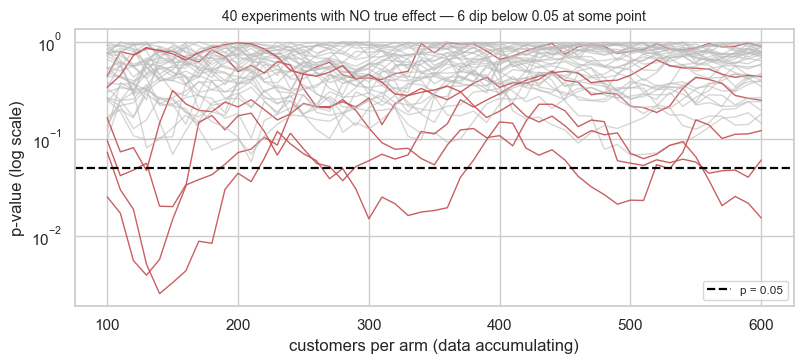

In [15]:
# A picture of the mechanism: p-value paths for 40 experiments with NO true effect.
pre_v, post_v, tr_v = simulate_many(40, 0.0, seed=5)
pmv = pre_v.mean(1, keepdims=True); omv = post_v.mean(1, keepdims=True)
thv = (((pre_v - pmv) * (post_v - omv)).sum(1, keepdims=True)
       / ((pre_v - pmv) ** 2).sum(1, keepdims=True))
yv = post_v - thv * (pre_v - pmv)
av, bv = yv[:, tr_v], yv[:, ~tr_v]
paths = np.empty((40, len(LOOKS)))
for j, k in enumerate(LOOKS):
    ma, mb = av[:, :k].mean(1), bv[:, :k].mean(1)
    se = np.sqrt(av[:, :k].var(1, ddof=1) / k + bv[:, :k].var(1, ddof=1) / k)
    paths[:, j] = 2 * stats.norm.sf(np.abs((ma - mb) / se))

fig, ax = plt.subplots(figsize=(8.2, 3.8))
crossed = (paths < 0.05).any(1)
for i in range(40):
    ax.plot(LOOKS, paths[i], lw=1.0,
            color="#c44e52" if crossed[i] else "#bbbbbb",
            alpha=0.9 if crossed[i] else 0.6)
ax.axhline(0.05, color="black", lw=1.6, ls="--", label="p = 0.05")
ax.set_yscale("log"); ax.set_xlabel("customers per arm (data accumulating)")
ax.set_ylabel("p-value (log scale)")
ax.set_title(f"40 experiments with NO true effect — {crossed.sum()} dip below 0.05 "
             f"at some point", fontsize=10)
ax.legend(fontsize=8.5); plt.tight_layout(); plt.show()

The grey paths wander; the red ones dip under the line at least once and would have been declared winners by anyone watching. None of them has a real effect.

### The fix: decide the stopping rule before you start

Three honest options, in increasing order of sophistication:

1. **Fixed horizon.** Pre-register the sample size from §2's MDE calculation, look once, and make peeking socially impossible by not building the mid-flight dashboard. Cheapest and most robust.
2. **A corrected boundary.** Keep looking, but require a *stricter* threshold at each look so the family-wise rate is still 5 %. We can find that threshold the same way we found the problem — by simulation.
3. **Always-valid inference** (confidence sequences, mixture-SPRT). Bounds designed to hold at *every* sample size simultaneously, so continuous monitoring is legitimate and you can stop as soon as the evidence is there. This is what modern experimentation platforms run. Stretch B builds one.

Option 2 by Monte Carlo is a genuinely useful trick: no lookup tables, no assumptions about the metric's distribution, just "simulate my own design under the null and find the threshold that behaves."

In [16]:
print("calibrating a constant per-look threshold (Pocock-style) by simulation")
print(f"{'per-look alpha':>15} {'family-wise FP':>16}")
for a in (0.05, 0.02, 0.01, 0.008, 0.005):
    print(f"{a:>15.3f} {peek_rates(a)[0]:>16.1%}")
print("\n-> a per-look threshold of about 0.008 restores the 5 % guarantee "
      "across all 51 looks.")

calibrating a constant per-look threshold (Pocock-style) by simulation
 per-look alpha   family-wise FP
          0.050            22.6%


          0.020             9.8%


          0.010             5.8%
          0.008             4.9%


          0.005             3.2%

-> a per-look threshold of about 0.008 restores the 5 % guarantee across all 51 looks.


Roughly **0.008** — about a sixth of the nominal 0.05 — buys back the guarantee for this design. That is the real price of watching: not "you may not look", but "if you look 51 times, each look must clear a much higher bar."

The cost is power. A stricter threshold at every look means a real effect takes longer to declare, which is exactly the trade-off group-sequential designs formalise (spend little α early, more late — Practice 2). There is no free lunch; there is only an honest accounting.

---

### ✋ Quick exercise (~2 min) — does looking *less often* help?

The team compromises: instead of nightly, they'll check **weekly** — 8 looks over the 8-week test instead of 51.

Use `peek_rates` with a coarser look schedule to find the false-positive rate at α = 0.05 with 8 looks. Is "look less often" an adequate fix?

```python
weekly = np.linspace(HALF / 8, HALF, 8).astype(int)   # 8 evenly spaced looks
```

In [17]:
# ✍️ Your turn 👇
weekly = np.linspace(HALF / 8, HALF, 8).astype(int)
# false-positive rate with 8 looks vs 51 looks, at alpha = 0.05:

<details>
<summary>✅ <b>Solution</b></summary>

```python
weekly = np.linspace(HALF / 8, HALF, 8).astype(int)
for label, looks in [("51 looks (nightly)", LOOKS), ("8 looks (weekly)", weekly),
                     ("3 looks", np.linspace(HALF / 3, HALF, 3).astype(int)),
                     ("1 look (fixed horizon)", np.array([HALF]))]:
    print(f"{label:24s} false-positive rate {peek_rates(0.05, looks=looks)[0]:.1%}")
```

Weekly looks cut the false-positive rate to roughly **15 %** — a big improvement over 23 %, and still **three times** the rate anyone thinks they are running. Three looks give ~11 %. Only the single pre-specified look lands on 5 %.

So "look less often" is a *mitigation*, not a fix, and it is the mitigation people reach for because it feels like restraint. The lesson generalises beyond peeking: any decision rule that gets applied repeatedly to accumulating data needs its threshold corrected for the number of applications, whether those are looks over time (§5), metrics (§6), or subgroups (Stretch D).
</details>

## 6. Two checks before you interpret anything

Before reading an effect size, ask whether the experiment ran. Two checks catch most invalid tests, and both are one line.

### Sample-ratio mismatch (SRM)

You asked for a 50/50 split. If the realised split differs by more than chance, **the assignment mechanism is broken** — a redirect that drops slow connections, a bot filter applied to one arm, a caching layer serving control to logged-out users, an SDK that fails open. When SRM fires, the arms are no longer comparable and the effect size is uninterpretable. You do not adjust for SRM; you find the bug and throw the data away.

A chi-square goodness-of-fit test against the intended ratio is the standard check.

In [18]:
def srm_check(counts, expected_ratio=(0.5, 0.5)):
    n = sum(counts)
    exp = [n * r for r in expected_ratio]
    chi2 = sum((o - e) ** 2 / e for o, e in zip(counts, exp))
    return chi2, stats.chi2.sf(chi2, len(counts) - 1)

print("D1's checkout test, session-level assignment over 4 weeks:")
print(f"{'observed split':>24} {'share':>16} {'chi2':>9} {'p':>11}  verdict")
for counts in [(9_980, 10_020), (10_240, 9_760), (10_500, 9_500)]:
    chi2, p = srm_check(counts)
    print(f"{str(counts):>24} {counts[0] / sum(counts):>15.2%} {chi2:>9.2f} {p:>11.2e}"
          f"  {'OK' if p > 0.001 else 'SRM -- INVALID, do not interpret'}")

D1's checkout test, session-level assignment over 4 weeks:
          observed split            share      chi2           p  verdict
           (9980, 10020)          49.90%      0.08    7.77e-01  OK
           (10240, 9760)          51.20%     11.52    6.89e-04  SRM -- INVALID, do not interpret
           (10500, 9500)          52.50%     50.00    1.54e-12  SRM -- INVALID, do not interpret


The middle row is the one to sit with: **51.2 % / 48.8 %** looks like nothing. A product manager would glance at it and move on. At 20,000 sessions it is a p = 0.0007 red flag, and whatever lift that test reported is not a lift.

That is the useful property of SRM: it becomes detectable exactly when it becomes dangerous. The conventional threshold is a strict one (p < 0.001) precisely because the cost of ignoring a real SRM is a wrong decision, while the cost of a false alarm is an afternoon of debugging.

### The multiple-comparisons tax

The second check is about how many questions you asked. Every metric on the dashboard is another 5 % chance of a spurious win.

In [19]:
rm = np.random.default_rng(3)
print("all metrics genuinely null; how often does at least one 'win'?")
print(f"{'metrics':>8} {'simulated':>11} {'theory':>9} {'Bonferroni alpha':>18}")
for m in (1, 5, 12, 20):
    ps = rm.random((20_000, m))
    print(f"{m:>8} {(ps.min(1) < 0.05).mean():>11.1%} {1 - 0.95 ** m:>9.1%} "
          f"{0.05 / m:>18.4f}")

all metrics genuinely null; how often does at least one 'win'?
 metrics   simulated    theory   Bonferroni alpha
       1        5.2%      5.0%             0.0500


       5       22.8%     22.6%             0.0100
      12       45.7%     46.0%             0.0042
      20       63.9%     64.2%             0.0025


Twelve metrics — a modest dashboard — and there is a **46 %** chance that at least one shows a spurious significant "win". Scan twenty and it is a coin flip you are guaranteed to win.

The fix is not statistical austerity, it is deciding *in advance* what the experiment is for:

- **One primary metric**, chosen before the test, judged at α = 0.05. This is the decision.
- **Secondary metrics** are exploratory. Report them with a correction (Bonferroni `α/m` is crude but honest; Holm–Bonferroni is uniformly better and just as easy) and never let one of them rescue a failed primary.
- **Guardrail metrics** (latency, error rate, refunds, unsubscribes) are watched for *harm*, not for wins — a one-sided question with a different threshold, because you would rather over-detect damage.

Practice exercise 3 is what happens when nobody does this.

## 7. From p-value to decision — and the winner's curse

A significant p-value is not a decision, for exactly the reason a churn probability wasn't one in NB 23. The decision needs euros: the effect size, its uncertainty, the traffic it applies to, and what shipping costs.

But there is a trap between the result and the decision, and it is the most expensive idea in this notebook.

**Selecting on significance biases the effect size upward.** A test crosses the significance line when the true effect is large *or* when the noise happened to help. So the pool of "winners" is enriched with lucky draws, and their measured lifts overstate what you will actually get. This is the **winner's curse**, and its severity depends on one thing you now know how to control: **power**.

Let's measure it. We simulate 4,000 experiments where 30 % of ideas are genuinely good (~+9 %) and 70 % do nothing, then compare the *measured* lift of the winners against their *true* lift — once with the underpowered raw analysis, once with CUPED.

In [20]:
K = 4000
rr = np.random.default_rng(7)
is_real = rr.random(K) < 0.30
true_lifts = np.where(is_real, np.abs(rr.normal(0.09, 0.03, K)), 0.0)

pre_k, post_k, tr_k = simulate_many(K, 0.0, seed=99)
post_k = post_k * (1 + np.where(tr_k, true_lifts[:, None], 0.0))
pmk = pre_k.mean(1, keepdims=True); omk = post_k.mean(1, keepdims=True)
thk = (((pre_k - pmk) * (post_k - omk)).sum(1, keepdims=True)
       / ((pre_k - pmk) ** 2).sum(1, keepdims=True))
adj_k = post_k - thk * (pre_k - pmk)

curse = {}
summary = []
for name, y in (("raw", post_k), ("CUPED", adj_k)):
    rel, p = welch_rows(y, tr_k)
    w = p < 0.05
    curse[name] = dict(rel=rel, p=p, won=w)
    summary.append(dict(analysis=name, share_significant=w.mean(),
                        measured=rel[w].mean(), true=true_lifts[w].mean(),
                        overstated=rel[w].mean() / true_lifts[w].mean() - 1,
                        false_discoveries=(true_lifts[w] == 0).mean()))
print(pd.DataFrame(summary).set_index("analysis").to_string(
    formatters={"share_significant": "{:.1%}".format, "measured": "{:+.2%}".format,
                "true": "{:+.2%}".format, "overstated": "{:+.0%}".format,
                "false_discoveries": "{:.0%}".format}))

         share_significant measured   true overstated false_discoveries
analysis                                                               
raw                  15.9%  +11.73% +7.82%       +50%               23%
CUPED                27.0%   +9.14% +8.46%        +8%               13%


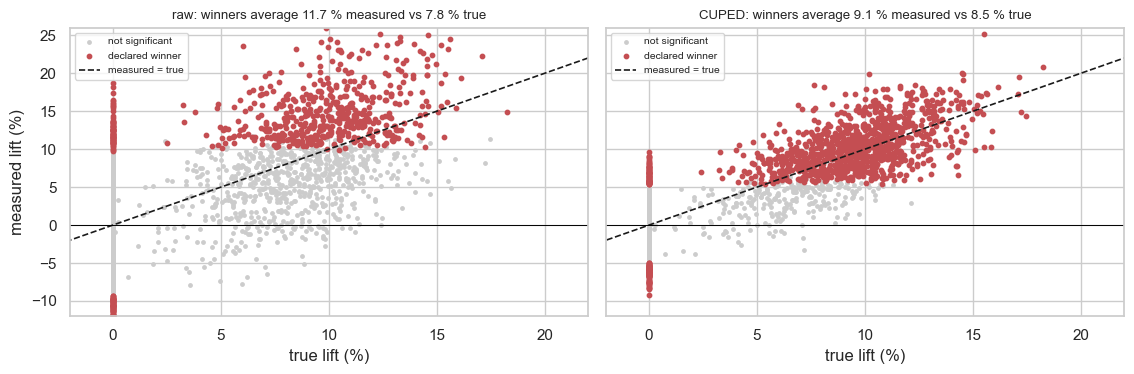

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), sharey=True)
for ax, name in zip(axes, ("raw", "CUPED")):
    rel, w = curse[name]["rel"], curse[name]["won"]
    ax.scatter(true_lifts[~w] * 100, rel[~w] * 100, s=6, color="#cccccc",
               label="not significant")
    ax.scatter(true_lifts[w] * 100, rel[w] * 100, s=10, color="#c44e52",
               label="declared winner")
    lim = [-12, 26]
    ax.plot(lim, lim, "k--", lw=1.2, label="measured = true")
    ax.axhline(0, color="black", lw=0.7)
    ax.set_xlim(-2, 22); ax.set_ylim(*lim)
    ax.set_xlabel("true lift (%)")
    ax.set_title(f"{name}: winners average "
                 f"{rel[w].mean() * 100:.1f} % measured vs "
                 f"{true_lifts[w].mean() * 100:.1f} % true", fontsize=9.5)
    ax.legend(fontsize=7.5, loc="upper left")
axes[0].set_ylabel("measured lift (%)")
plt.tight_layout(); plt.show()

Read the left panel. The red dots — the experiments a company would celebrate and ship — sit **systematically above** the diagonal. Many of them have a true lift of exactly zero and a measured lift of +10 % or more. With the underpowered analysis, winners overstate their lift by about **50 %**, and roughly **a quarter of them are pure noise**.

Now the right panel. Same ideas, same data, same 5 % threshold — only the variance reduction from §4 is different. Overstatement falls to about **8 %** and false discoveries roughly halve.

> 🧭 **The idea to take away.** Power is usually sold as insurance against missing real effects. It is also **the thing that makes your measured effects trustworthy**. A low-powered testing programme does not merely find fewer wins; the wins it does find are inflated and partly fictional, so the roadmap gets built on numbers that never materialise, and the annual "why didn't our shipped experiments add up to the forecast?" post-mortem has a statistical answer.

Three practical defences, in order of how much you should rely on them:

1. **Power the test properly** (§2, §4). This attacks the cause.
2. **Plan on the conservative end of the interval**, not the point estimate. Our CUPED interval is [+2.2 %, +13.6 %] — build the business case on the +2.2 %, and treat the +7.9 % point estimate as the upside.
3. **Keep a holdback.** Ship to 90 %, hold 10 % back, and measure the realised effect for a quarter. It is the only way to learn your own organisation's haircut — and once you know it, you can apply it to the next forecast.

In [22]:
# The decision, in euros. D2's loyalty offer, using the CUPED estimate.
CUSTOMERS = 1200
BASELINE_Q = float(post[~treated].mean())       # revenue per customer over 8 weeks
MARGIN_RATE = 0.34                              # webshop contribution margin (A1)
OFFER_COST = 42.0                               # free delivery, per enrolled customer/year
ROLLOUT_COST = 18_000                           # build + ops, one-off

def annual_value(rel_lift):
    extra_rev = CUSTOMERS * BASELINE_Q * rel_lift * (52 / 8)   # 8-week window -> year
    return extra_rev * MARGIN_RATE - CUSTOMERS * OFFER_COST

print(f"baseline revenue/customer/8wks  {BASELINE_Q:,.0f} EUR")
print(f"{'scenario':>26} {'lift':>8} {'annual margin':>15} {'net of rollout':>16}")
for label, lift in (("CI lower bound", cup["lo"]), ("point estimate", cup["rel"]),
                    ("CI upper bound", cup["hi"]), ("the truth (unknowable)", TRUE_LIFT)):
    v = annual_value(lift)
    print(f"{label:>26} {lift:>+8.2%} {v:>15,.0f} {v - ROLLOUT_COST:>16,.0f}")

baseline revenue/customer/8wks  874 EUR
                  scenario     lift   annual margin   net of rollout
            CI lower bound   +2.18%              30          -17,970
            point estimate   +7.87%         131,994          113,994
            CI upper bound  +13.56%         263,957          245,957
    the truth (unknowable)   +9.00%         158,235          140,235


### The memo

| Decision | Verdict | Why |
|---|---|---|
| **D1 · checkout redesign** | **Don't test — ship or drop on judgement** | The 4-week test resolves ±0.99 pp against a hypothesis of +0.5 pp. It would return "no significant difference" regardless of the truth. Either commit to 16 weeks, raise the action threshold to +1 pp, or decide without a test and monitor guardrails |
| **D2 · loyalty offer** | **Roll out, with a 10 % holdback** | Central case ≈ **+€114k/year** net of rollout; the *conservative* end of the interval is a ≈**−€18k** loss. Strongly positive expected value against a small, capped downside — and the holdback measures the realised effect, calibrating our winner's-curse haircut for next time |
| **D3 · monitor price** | **Test — design in Stretch C** | 12 regions is a clustered design; the naive per-week power calculation in A1's Stretch C flatters it badly |

Note what carried D2, because it is *not* the p-value. It is the **shape of the interval against the cost of acting**: the upside is an order of magnitude larger than the downside, and the downside is bounded and observable. Had the conservative end implied a €500k loss, the same p = 0.007 would not have been enough.

> ⚠️ **The offer cost is doing a lot of work here.** €42 per customer per year against a ~€5,700 annual spend is the assumption that makes the downside small. Sensitivity-test the *cost* side of a decision like this as carefully as the lift: at €60 per customer the conservative case loses €40k and the recommendation changes to "pilot on the highest-spending quintile first."

---

### ✋ Quick exercise (~2 min) — would you have shipped on the raw analysis?

Re-run the euro table using the **raw** (non-CUPED) result instead. Its point estimate was +5.0 % with a much wider interval. Does the decision change — and which number changes it?

```python
print(raw["lo"], raw["rel"], raw["hi"])
```

In [23]:
# ✍️ Your turn 👇
# Annual value at the raw analysis's CI lower bound, point estimate and upper bound:

<details>
<summary>✅ <b>Solution</b></summary>

```python
print(f"{'scenario':>22} {'lift':>8} {'annual margin':>15} {'net':>13}  ship?")
for label, lift in (("raw CI lower", raw["lo"]), ("raw point", raw["rel"]),
                    ("raw CI upper", raw["hi"])):
    v = annual_value(lift) - ROLLOUT_COST
    print(f"{label:>22} {lift:>+8.2%} {annual_value(lift):>15,.0f} {v:>13,.0f}"
          f"  {'yes' if v > 0 else 'NO'}")
```

The raw point estimate is *positive and profitable* (≈ +€59k net), but the interval's lower bound implies a **six-figure loss** — the raw analysis is genuinely consistent with the offer destroying a lot of money. A decision-maker weighing that upside against that downside refuses, and correctly refuses **the right idea**.

Compare the two intervals as *decisions* rather than as statistics. Raw: −€167k to +€246k, a coin flip on a large bet. CUPED: −€18k to +€246k, a small bounded downside against a large upside. The point estimates barely differ; the **decisions** are opposite.

That is the honest cost of low power, stated as a business outcome rather than a statistic: it does not just fail to prove good ideas, it makes them **indistinguishable from bad ones**, so a disciplined decision process rejects them. The fix is not to loosen the decision rule — it is to build a test whose interval is narrow enough to act on. CUPED did that here for free.
</details>

## 8. What real experimentation platforms add (honest section)

- **Interference.** We assumed one customer's treatment doesn't affect another's outcome. In marketplaces, social products and shared-inventory settings that is false: give one buyer a discount and the stock another buyer wanted is gone. The patches are cluster randomization, **switchback** designs (alternate treatment over time for everyone) and budget-split designs.
- **Clustered assignment.** Randomizing sites, regions or accounts instead of individuals inflates the required sample by the **design effect** `1 + (m−1)ρ_ICC`, which is brutal for large clusters. Stretch A works it out; D3 needs it.
- **Always-valid inference.** Confidence sequences and mixture-SPRT bounds legitimise continuous monitoring, which is what a real platform must support because humans *will* look. Stretch B.
- **Heterogeneous effects.** An average lift of zero can hide +15 % for one segment and −15 % for another. Estimating that honestly is uplift/CATE modelling (NB 23's "sleeping dogs" caveat), and it walks straight into §6's multiple-comparisons problem. Stretch D.
- **Quasi-experiments.** Sometimes you cannot randomize — pricing across a whole market, a regulatory change, a brand campaign. Difference-in-differences, synthetic control and geo-lift designs are the tools, and they trade a clean identification argument for feasibility (the same trade A1 made with controls).
- **Sequential decision-making.** Bandits reallocate traffic to winners *during* the test. They optimise cumulative reward rather than inferential cleanliness, so they are right for headline choices and wrong when you need a defensible effect size.
- **Ethics and consent.** Experimenting on people has limits that statistics does not set: informed consent, harm, price discrimination (A1 §7), vulnerable users, and the difference between a UI test and an intervention in someone's finances. Some experiments should not be run whatever their power.
- **Organisational plumbing.** Pre-registration, a metrics repository with agreed definitions, automated SRM and guardrail alerting, and an experiment review board. The statistics in this notebook are the easy part; the culture that stops people peeking is the hard part.

---

## 🧠 The story in one screen

1. **An experiment is an instrument with a resolution.** Compute the **MDE** first. D1's 4-week test resolves ±0.99 pp against a +0.5 pp hypothesis, so its answer was knowable in advance — and wrong.
2. **"Not significant" is not "no effect."** D2's raw analysis reported +5.0 %, p = 0.29, and recommended shutting down an offer that genuinely lifts revenue 9 %. Simulation put the false-negative rate at **~61 %**.
3. **CUPED bought the power back for free.** Pre-period revenue correlates 0.82 with post, variance falls by ρ² ≈ 66 %, the MDE drops from 13.6 % to ~8 %, and power goes **39 % → 86 %** on the same customers in the same eight weeks. The CI narrowed from 19.5 points to 11.4, and the verdict flipped from "not significant" to p = 0.007.
4. **Peeking breaks the guarantee.** 51 looks turned a 5 % test into a **23 %** test; looking weekly instead only got it to ~15 %. Fix the horizon, or correct the boundary (~0.008 per look here), or use always-valid bounds.
5. **Check that the experiment ran** before interpreting it: SRM (a bland-looking 51.2/48.8 split is p = 0.0007) and the multiple-comparisons tax (12 metrics → 46 % chance of a spurious winner).
6. **The winner's curse links it all together.** Selecting on significance inflates effect sizes — by **+50 %** under the underpowered analysis versus **+8 %** with CUPED. Power is not only insurance against missing effects; it is what makes the effects you find real.

> 🧭 **Mental model, one last time.** In NB 23 the exchange rate from model to action was `p · s · CLV`; in NB 24 analyst capacity; in NB 26 the critical ratio; in A1 elasticity against contribution margin. Here it is the **confidence interval against the cost of acting** — you ship when the conservative end of the interval still pays. And the whole notebook is one lesson wearing five costumes: **a result means nothing until you know what your instrument could have detected.**

## 🧪 Practice exercises

Try each one **before** opening the solution. Starters run as-is.

### Exercise 1 — ⭐ The test-planning table
Write `weeks_needed(base_rate, rel_lift, sessions_per_week, alpha=0.05, power=0.80)` returning the weeks a two-arm test needs to detect a *relative* lift on a conversion metric. Produce the table a product manager actually wants: rows = relative lifts (5 %, 10 %, 20 %, 30 %), columns = weekly traffic (2,500, 10,000, 50,000), cells = weeks. Then say which cells are feasible.

In [24]:
# Starter
def weeks_needed(base_rate, rel_lift, sessions_per_week, alpha=0.05, power=0.80):
    ...  # absolute delta = base_rate * rel_lift; use n_prop, then 2 arms / traffic

# build the table with a dict comprehension + pd.DataFrame

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def weeks_needed(base_rate, rel_lift, sessions_per_week, alpha=0.05, power=0.80):
    delta = base_rate * rel_lift
    n = n_prop(base_rate, delta, alpha, power)
    return 2 * n / sessions_per_week

lifts = [0.05, 0.10, 0.20, 0.30]
traffic = [2_500, 10_000, 50_000]
tbl = pd.DataFrame({f"{t:,}/wk": [weeks_needed(BASE_CVR, L, t) for L in lifts]
                    for t in traffic},
                   index=[f"{L:.0%} lift" for L in lifts])
print(tbl.round(1).to_string())
print("\nfeasible (<= 6 weeks):")
print((tbl <= 6).to_string())
```

At the webshop's 2,500 sessions/week almost nothing is feasible: even a **30 %** relative lift needs ~4 weeks, and 10 % needs about 39. At 50,000 sessions/week a 10 % lift lands inside two weeks.

The table is the artefact worth keeping, because it reframes the conversation. "We can't test that" sounds like an excuse; a table showing that a 5 % lift needs **152 weeks** at current traffic is an argument — and it points at the two real options, which are *get more traffic into the test* (all users, not a 10 % ramp; pool related surfaces) or *stop trying to detect 5 %*. Note the 1/Δ² scaling: halving the lift you want to detect quadruples the time.
</details>

### Exercise 2 — ⭐⭐ Spend your alpha unevenly
§5 used a *constant* per-look threshold. Group-sequential designs do better by spending little α early and more late — an **O'Brien–Fleming-style** boundary, which barely allows early stopping but keeps almost the full α for the final look. Implement a boundary of the form `alpha_k = alpha * (k/K) ** g` (α spent by look *k* of *K*), calibrate `g` by simulation so the family-wise rate is 5 %, and compare its **power** against the constant-0.008 boundary.

In [25]:
# Starter — sketch:
# def spend_schedule(alpha, K, g): return alpha * (np.arange(1, K+1) / K) ** g
# adapt peek_rates to take a per-look alpha ARRAY, then compare:
#   (a) constant 0.008        (b) increasing schedule
# on BOTH the null (false-positive rate) and lift=0.09 (power)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def peek_rates_sched(alphas, n_sims=3000, lift=0.0, seed=11, looks=LOOKS):
    pre_p, post_p, tr = simulate_many(n_sims, lift, seed)
    pmn = pre_p.mean(1, keepdims=True); omn = post_p.mean(1, keepdims=True)
    thp = (((pre_p - pmn) * (post_p - omn)).sum(1, keepdims=True)
           / ((pre_p - pmn) ** 2).sum(1, keepdims=True))
    y = post_p - thp * (pre_p - pmn)
    a, b = y[:, tr], y[:, ~tr]
    ca, cb = np.cumsum(a, 1), np.cumsum(b, 1)
    ca2, cb2 = np.cumsum(a**2, 1), np.cumsum(b**2, 1)
    ever = np.zeros(n_sims, dtype=bool)
    for al, k in zip(alphas, looks):
        ma, mb = ca[:, k-1]/k, cb[:, k-1]/k
        va = (ca2[:, k-1] - k*ma**2)/(k-1); vb = (cb2[:, k-1] - k*mb**2)/(k-1)
        ever |= 2 * stats.norm.sf(np.abs((ma - mb) / np.sqrt(va/k + vb/k))) < al
    return ever.mean()

K = len(LOOKS)
def sched(g, scale):    # increasing schedule, scaled to hit 5 % family-wise
    return scale * (np.arange(1, K + 1) / K) ** g

for g in (2.0, 3.0):
    lo, hi = 1e-4, 0.20                      # bisect the scale
    for _ in range(14):
        mid = (lo + hi) / 2
        if peek_rates_sched(sched(g, mid)) > 0.05: hi = mid
        else: lo = mid
    a_sched = sched(g, lo)
    fp = peek_rates_sched(a_sched)
    pw = peek_rates_sched(a_sched, lift=TRUE_LIFT, seed=21)
    print(f"g={g}: scale {lo:.4f} | first look alpha {a_sched[0]:.5f} "
          f"last {a_sched[-1]:.4f} | FP {fp:.1%} | power {pw:.1%}")

const = np.full(K, 0.008)
print(f"constant 0.008: FP {peek_rates_sched(const):.1%} | "
      f"power {peek_rates_sched(const, lift=TRUE_LIFT, seed=21):.1%}")
print(f"fixed horizon : FP {peek_rates_sched(np.r_[np.zeros(K-1), 0.05]):.1%} | "
      f"power {peek_rates_sched(np.r_[np.zeros(K-1), 0.05], lift=TRUE_LIFT, seed=21):.1%}")
```

The increasing schedule wins on power at the same false-positive rate: it declines to stop early on thin evidence (the first look's threshold is minuscule) and in exchange keeps a final-look threshold close to the full 0.05, so it loses far less power than a flat 0.008 applied 51 times.

That is the general principle behind group-sequential designs: **α is a budget, and spending it early is expensive** because early looks are the noisiest and the least likely to be right. The fixed-horizon row is the ceiling — no monitoring, maximum power — and the gap between it and your chosen boundary is precisely the price of being allowed to look.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the dashboard that found a winner
A colleague reports: *"The new supplier-badge feature is a win — logged-in add-to-cart is up 4.1 %, p = 0.015."* Their code runs and the arithmetic is right. In the generator below **every metric is null** — the feature does nothing to anything. Find the two bugs that manufactured a winner.

In [26]:
# A colleague's analysis. The feature has NO effect on any metric.
rng_bug = np.random.default_rng(80)
n_arm = 600
METRICS = ["conversion", "add_to_cart", "revenue_per_session", "items_per_order",
           "search_use", "return_rate", "signup", "logged_in_add_to_cart",
           "mobile_conversion", "desktop_conversion", "repeat_visit", "wishlist_add"]

results = []
for m in METRICS:
    a = rng_bug.normal(100, 30, n_arm)      # treatment -- drawn from exactly the
    b = rng_bug.normal(100, 30, n_arm)      # same distribution as control
    t, p = stats.ttest_ind(a, b)
    results.append({"metric": m, "lift": a.mean() / b.mean() - 1, "p": p})

res = pd.DataFrame(results).sort_values("p")
print(res.to_string(index=False, formatters={"lift": "{:+.2%}".format, "p": "{:.3f}".format}))

# "obviously we only care about the metrics that went UP"
best = res[res.lift > 0].iloc[0]
print(f"\nHEADLINE: {best['metric']} is up {best['lift']:+.1%} "
      f"(p = {best['p']:.3f}) -- ship it!")

               metric   lift     p
logged_in_add_to_cart +4.14% 0.015
               signup -2.21% 0.207
         repeat_visit -2.12% 0.229
      items_per_order +2.02% 0.240
           conversion +2.08% 0.248
          add_to_cart +1.43% 0.391
    mobile_conversion -1.28% 0.432
           search_use -1.14% 0.509
   desktop_conversion -0.89% 0.608
  revenue_per_session -0.86% 0.618
         wishlist_add +0.38% 0.826
          return_rate -0.23% 0.889

HEADLINE: logged_in_add_to_cart is up +4.1% (p = 0.015) -- ship it!


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

**Bug 1 — twelve metrics, one threshold.** With 12 null metrics the chance that at least one lands under p = 0.05 is `1 − 0.95¹² ≈ 46 %` (§6). Reporting the *smallest* p-value out of twelve and judging it at 0.05 is not a test, it is a search. The printed p-value answers "is this metric significant in isolation?", but the question actually asked was "did any of twelve move?", and those two have very different null distributions.

**Bug 2 — the winner was filtered and chosen after the fact.** Look at the `res[res.lift > 0]` line: metrics that went *down* were silently discarded before picking the headline. That halves the search space in one direction and turns a two-sided test into a one-sided fishing trip — on top of which `logged_in_add_to_cart` was never the pre-registered primary metric. It became the headline because it won. Note it is also a *subgroup* of a metric (logged-in users × add-to-cart); subgroup × metric multiplies the search space, and the narrative ("badges build trust, so logged-in buyers respond") is always available after the fact.

```python
m = len(METRICS)
res2 = res.copy()
# Bonferroni and the uniformly-better Holm-Bonferroni
res2["bonferroni_alpha"] = 0.05 / m
res2["holm_alpha"] = 0.05 / (m - np.arange(m))          # res is sorted by p
res2["survives_bonf"] = res2.p < res2.bonferroni_alpha
res2["survives_holm"] = res2.p < res2.holm_alpha
print(res2.to_string(index=False, formatters={"lift": "{:+.2%}".format,
      "p": "{:.3f}".format, "bonferroni_alpha": "{:.4f}".format,
      "holm_alpha": "{:.4f}".format}))
print(f"\nsurvives Bonferroni: {int(res2.survives_bonf.sum())} of {m}")
print(f"P(at least one p<0.05 | all null) = {1 - 0.95 ** m:.1%}")
```

Nothing survives either correction, which is the correct answer: the feature does nothing.

**The fix is procedural, not statistical.** Name one primary metric before the test starts and judge it at 0.05. Treat everything else as exploratory, correct it, and require replication before anyone builds a roadmap on it. Guardrails are the exception — you watch those for *harm* one-sided, because under-detecting damage is the costlier error.
</details>

### Exercise 4 — ⭐⭐ Trigger dilution: how much does it really cost?
Only **38 %** of sessions ever reach the checkout step D1 changes; the rest cannot possibly be affected. The received wisdom is that analysing all randomized sessions "dilutes" your effect and wrecks power, so you should always restrict to *triggered* users (triggered conversion rate: 8.4 %).

Test that claim. Compute the MDE both ways, expressed as a **relative effect on the triggered population** so they are comparable, and take the ratio. Then work out algebraically what that ratio depends on — and when the received wisdom is actually right.

In [27]:
# Starter
TRIGGER_RATE, CVR_TRIGGERED = 0.38, 0.084
n_all = SESSIONS_WK / 2 * 4
# (a) MDE on all sessions -- remember the effect on the FULL population is
#     only TRIGGER_RATE x the effect on triggered users
# (b) MDE on triggered sessions only
# Express both per unit of triggered-user effect, then take the ratio.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
TRIGGER_RATE, CVR_TRIGGERED = 0.38, 0.084
n_all = SESSIONS_WK / 2 * 4
n_trig = n_all * TRIGGER_RATE
cvr_all = CVR_TRIGGERED * TRIGGER_RATE        # diluted rate over everyone

mde_all = mde_prop(cvr_all, n_all) / TRIGGER_RATE      # per unit of triggered effect
mde_trig = mde_prop(CVR_TRIGGERED, n_trig)

print(f"{'analysis':>16} {'n/arm':>8} {'base':>8} {'MDE on triggered effect':>25}")
print(f"{'all sessions':>16} {n_all:>8,.0f} {cvr_all:>8.2%} "
      f"{mde_all:>13.4f} = {mde_all / CVR_TRIGGERED:>6.1%} rel")
print(f"{'triggered only':>16} {n_trig:>8,.0f} {CVR_TRIGGERED:>8.2%} "
      f"{mde_trig:>13.4f} = {mde_trig / CVR_TRIGGERED:>6.1%} rel")
print(f"\nratio (all / triggered): {mde_all / mde_trig:.3f}x")

# the algebra: for a binary metric where untriggered users convert at 0,
# ratio = sqrt((1 - t*p) / (1 - p))
t, p = TRIGGER_RATE, CVR_TRIGGERED
print(f"closed form sqrt((1 - t*p)/(1 - p)) = {np.sqrt((1 - t * p) / (1 - p)):.3f}x")
print("\nhow the penalty grows with the base rate:")
for p_ in (0.02, 0.084, 0.25, 0.50, 0.80):
    print(f"  triggered rate {p_:>5.0%} -> dilution penalty "
          f"{np.sqrt((1 - t * p_) / (1 - p_)):.2f}x")
```

**The received wisdom is wrong here.** The ratio is **1.03×** — analysing all 5,000 sessions is within 3 % of the MDE you would get from the 1,900 triggered ones. Dilution cost essentially nothing.

The algebra says why. For a binary metric where untriggered users convert at zero, the penalty is `√((1 − t·p)/(1 − p))`, which → 1 as p → 0. Rare events carry almost all of their variance in the "did it happen at all" term, so adding users who never convert adds proportionally as little noise as it does signal. The last table shows the penalty only becoming serious at high base rates (1.15× at p = 50 %, 1.7× at p = 80 %).

Where dilution *does* bite: **continuous metrics** (untriggered sessions still have revenue, and all of that variance is pure noise for your effect), **very low trigger rates**, and any case where the untriggered group is more variable than the triggered one. The "divide by t" intuition people quote is the effect on the *point estimate*, not on the signal-to-noise ratio — and it is the latter that sets power.

So the real reason to analyse triggered users is **interpretation**, not power: "+4 % for the people who saw the new checkout" is a statement about your change, while "+1.5 % overall" is a statement about your change *and* your traffic mix, and it will drift as the mix drifts.

**The catch, which is the genuinely dangerous part.** Filtering to "reached checkout" is only safe if the treatment cannot change *whether* someone triggers. If the redesign alters the path to checkout, triggering is itself an outcome, and conditioning on it breaks randomization — you are comparing different populations, the same post-treatment-conditioning error as NB 23's leakage. The safe pattern: log the trigger event from a point in the flow the treatment cannot influence, verify the trigger *rate* matches across arms (an SRM check on the triggered subset), and only then restrict.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Clustered randomization and the design effect
The webshop wants to test a new account-management model, randomized by **customer site** rather than by customer: 60 sites averaging 20 customers each. Outcomes within a site are correlated (same buyer, same budget) with an intra-cluster correlation ρ_ICC ≈ 0.15. Simulate this, show that the naive individual-level t-test's false-positive rate is badly inflated, then fix it two ways — aggregate to site means, and apply the **design effect** `1 + (m−1)ρ_ICC` to the sample size. How many *individuals* is this 1,200-customer test really worth?

In [28]:
# Starter — sketch:
# for each site: site_effect ~ N(0, sqrt(rho_icc) * sigma)
#                customer  ~ site_effect + N(0, sqrt(1-rho_icc) * sigma)
# 1. naive t-test on all 1,200 customers under the NULL -> false-positive rate
# 2. t-test on the 60 site means -> false-positive rate
# 3. design effect = 1 + (m-1)*rho_icc; effective n = 1200 / design_effect

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
SITES, PER_SITE, RHO_ICC = 60, 20, 0.15
SIGMA = 1.0

def clustered_trial(seed, lift=0.0):
    r = np.random.default_rng(seed)
    site_eff = r.normal(0, np.sqrt(RHO_ICC) * SIGMA, SITES)
    noise = r.normal(0, np.sqrt(1 - RHO_ICC) * SIGMA, (SITES, PER_SITE))
    y = site_eff[:, None] + noise
    treated_site = np.zeros(SITES, bool); treated_site[SITES // 2:] = True
    y = y + lift * treated_site[:, None]
    return y, treated_site

fp_naive, fp_agg = [], []
for s in range(2000):
    y, ts = clustered_trial(1000 + s)
    ind_t = stats.ttest_ind(y[ts].ravel(), y[~ts].ravel())
    agg_t = stats.ttest_ind(y[ts].mean(1), y[~ts].mean(1))
    fp_naive.append(ind_t.pvalue < 0.05); fp_agg.append(agg_t.pvalue < 0.05)

de = 1 + (PER_SITE - 1) * RHO_ICC
print(f"individual-level t-test on clustered data: FP {np.mean(fp_naive):.1%}  (should be 5 %)")
print(f"t-test on site means                     : FP {np.mean(fp_agg):.1%}")
print(f"\ndesign effect 1 + (m-1)*rho = 1 + {PER_SITE-1}*{RHO_ICC} = {de:.2f}")
print(f"effective sample size: {SITES*PER_SITE} individuals -> "
      f"{SITES*PER_SITE/de:.0f} ({1/de:.0%} of what you thought)")
print(f"MDE inflation: sqrt({de:.2f}) = {np.sqrt(de):.2f}x")
```

The individual-level test rejects far more often than 5 % — it treats 20 correlated customers as 20 independent facts. Aggregating to the 60 site means restores nominal control (it is a valid test on genuinely independent units, at the cost of throwing away within-site information; a mixed model or cluster-robust SEs recover some of it).

The design effect is the number to take to a planning meeting: at m = 20 and ρ_ICC = 0.15 it is **3.85**, so 1,200 clustered customers are worth about **312 independent ones** and every MDE is **1.96×** larger than the naive calculation promised. Note it is driven by *cluster size*, not cluster count — halving cluster size while doubling the number of clusters is a large win for the same total sample, which is why "randomize at the finest unit you can defend" is the standing advice.
</details>

### Stretch exercise B — ⭐⭐⭐ Always-valid inference from scratch
Build a **confidence sequence** so continuous monitoring becomes legitimate. Use a simple sub-Gaussian mixture bound: at sample size *n* per arm, the radius is

`R(n) = sigma * sqrt(2 * (1 + 1/(n*t2)) * log(sqrt(n*t2 + 1) / alpha) / n)`

for a tuning parameter `t2` (roughly the effect size you are powered for). Verify by simulation that the sequence's *ever*-crossing rate under the null is ≤ α across all 51 looks, then compare its stopping time on a true +9 % lift with the fixed-horizon test.

In [29]:
# Starter — sketch:
# def cs_radius(n, sigma, t2=0.05**2, alpha=0.05): ...
# at each look, the interval is (diff -/+ R); "significant" iff it excludes 0
# 1. null: share of experiments where the interval EVER excludes 0  (target <= 5 %)
# 2. lift: median look at which it first excludes 0, vs the fixed-horizon test

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def cs_radius(n, sigma, t2=0.01, alpha=0.05):
    """Radius of a sub-Gaussian mixture confidence sequence at n per arm."""
    return sigma * np.sqrt(2 * (1 + 1 / (n * t2)) *
                           np.log(np.sqrt(n * t2 + 1) / alpha) / n)

def cs_run(n_sims, lift, seed):
    pre_p, post_p, tr = simulate_many(n_sims, lift, seed)
    pmn = pre_p.mean(1, keepdims=True); omn = post_p.mean(1, keepdims=True)
    thp = (((pre_p - pmn) * (post_p - omn)).sum(1, keepdims=True)
           / ((pre_p - pmn) ** 2).sum(1, keepdims=True))
    y = post_p - thp * (pre_p - pmn)
    y = y / y.std(1, keepdims=True)                  # standardise -> sigma = 1
    a, b = y[:, tr], y[:, ~tr]
    ca, cb = np.cumsum(a, 1), np.cumsum(b, 1)
    ever = np.zeros(n_sims, bool); first = np.full(n_sims, np.nan)
    for k in LOOKS:
        diff = ca[:, k-1]/k - cb[:, k-1]/k
        excl = np.abs(diff) > cs_radius(k, np.sqrt(2.0))
        newly = excl & ~ever
        first[newly] = k
        ever |= excl
    return ever, first

ever0, _ = cs_run(3000, 0.0, 31)
everL, firstL = cs_run(3000, TRUE_LIFT, 32)
print(f"NULL: interval ever excludes 0 in {ever0.mean():.1%} of experiments "
      f"(target <= 5 %, across all {len(LOOKS)} looks)")
print(f"+9 % LIFT: detected in {everL.mean():.1%}; "
      f"median first detection at n/arm = {np.nanmedian(firstL):.0f} "
      f"(fixed horizon spends {HALF})")
print(f"radius at n=100: {cs_radius(100, np.sqrt(2.0)):.3f} | "
      f"n=600: {cs_radius(600, np.sqrt(2.0)):.3f} "
      f"(fixed-horizon 95 % half-width at n=600: "
      f"{1.96*np.sqrt(2.0/600):.3f})")
```

The sequence holds under the null across **every** look — here at **0.8 %**, comfortably inside the 5 % budget. That is the point of "always valid": the guarantee is uniform over sample sizes, so you may stop whenever you like, including "as soon as it looks good."

You pay for that in width, and the printout shows how much: at n = 600 the always-valid radius is **0.176** against the fixed-horizon 95 % half-width of **0.113**, roughly 55 % wider. So on a +9 % effect the sequence detects in **58 %** of experiments against CUPED's fixed-horizon 86 % — a real loss of power, and this particular bound is also visibly conservative (0.8 % against a 5 % budget), so a tighter one would recover some of it.

The trade is nonetheless the right one for a platform: humans *will* peek, and a conservative bound that stays honest under continuous monitoring beats a tight bound that silently becomes a 23 % test. And where it shines is large effects — it called the median detection at **n = 360** of a possible 600, so a clear winner stops early and frees the traffic for the next test.
</details>

### Stretch exercise C — ⭐⭐⭐ Design A1's monitor price test properly
A1 §5 concluded the monitor needed a price test, and A1's own Stretch C sized it at "1–4 weeks per arm" using weekly residual noise. That calculation quietly assumed 56 independent weekly observations. Redo it as the **clustered, 12-region** design it really is: 6 regions at €249, 6 at €289, weekly regional unit sales, with regional demand levels correlated over time. Use the pre-period regional volume as a CUPED covariate, apply Stretch A's design effect, and produce an honest duration and risk budget. Does the answer still fit in a quarter?

In [30]:
# Starter — sketch:
# 1. simulate 12 regions x 26 weeks of monitor unit sales; region random effect +
#    week noise; assign 6 regions to each price arm
# 2. analyse at the REGION level (mean weekly units per region), with the
#    pre-period regional mean as a CUPED covariate
# 3. power: what elasticity difference can 6-vs-6 regions detect over 8/13/26 weeks?
# 4. risk: margin lost if the high-price arm turns out to be the worse one

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
REGIONS, PRE_W = 12, 13
P_LO, P_HI, COST = 249.0, 289.0, 168.0
BASE_UNITS = 8.0                      # monitor units per region per week

def region_trial(seed, eps_true, weeks):
    r = np.random.default_rng(seed)
    region_level = np.exp(r.normal(0, 0.35, REGIONS))            # persistent
    def draw(w, price):
        mult = (price / P_LO) ** eps_true
        lam = BASE_UNITS * region_level[:, None] * mult
        return r.poisson(lam * np.ones((REGIONS, w)))
    pre = draw(PRE_W, P_LO)                                       # everyone at 249
    arm = np.zeros(REGIONS, bool); arm[REGIONS // 2:] = True
    post = np.where(arm[:, None], draw(weeks, P_HI), draw(weeks, P_LO))
    return pre.mean(1), post.mean(1), arm

def analyse(pre_m, post_m, arm):
    th = np.cov(post_m, pre_m, ddof=1)[0, 1] / np.var(pre_m, ddof=1)
    adj = post_m - th * (pre_m - pre_m.mean())
    return stats.ttest_ind(adj[arm], adj[~arm], equal_var=False).pvalue, adj

print(f"{'weeks':>6} {'power @ eps=-1.15':>18} {'power @ eps=-2.0':>17}")
for w in (8, 13, 26):
    pw = []
    for eps in (-1.15, -2.0):
        hits = [analyse(*region_trial(500 + s + 7919 * w, eps, w))[0] < 0.05
                for s in range(600)]
        pw.append(np.mean(hits))
    print(f"{w:>6} {pw[0]:>18.1%} {pw[1]:>17.1%}")

de = 1 + (26 - 1) * 0.0        # weeks within a region are NOT independent draws
print(f"\nunits of inference: {REGIONS} regions, not {REGIONS * 26} region-weeks")
q_lo = BASE_UNITS * REGIONS / 2
for eps in (-1.0, -2.0, -3.07, -4.0):
    lost = ((P_HI - COST) * q_lo * (P_HI / P_LO) ** eps - (P_LO - COST) * q_lo)
    print(f"if true eps = {eps:+.2f}: high arm {lost:>+9,.0f} EUR/week "
          f"-> 13-week arm {lost * 13:>+10,.0f} EUR")
```

**The honest answer is much worse than A1's Stretch C suggested.** The units of inference are **12 regions**, not 312 region-weeks — running longer shrinks the *within*-region sampling noise but never adds a thirteenth region. Power to detect ε = −1.15 climbs from **29 % at 8 weeks to just 54 % at 26 weeks** and never reaches 80 %: between-region variation (the `region_level` term) dominates, and CUPED on the pre-period only partly removes it.

That is the correct conclusion and it is a useful one: **the constraint is the number of clusters, so buy clusters, not weeks.** Practical routes: randomize at a finer unit (customer cohort or account rather than region — defensible for a B2B webshop where price is quoted per account), use a **switchback** design so every region contributes both arms over alternating periods, or accept a coarser question ("is elasticity above or below 1?" rather than "what is it?"). And A1's risk framing survives intact: the high-price arm only loses money once |ε| exceeds 1/CM = 3.07, so the downside is small and the honest blocker is resolution, not risk.
</details>

### Stretch exercise D — ⭐⭐⭐ Heterogeneous effects without fooling yourself
The loyalty offer's average lift is +9 %. Leadership asks which segments it works best for. Split D2's customers into 6 segments (by pre-period revenue quintile plus sector, say), estimate the lift within each, and count how often the *best* segment looks significant when the effect is in fact **identical everywhere**. Then implement one honest alternative: pre-registered segments with a correction, and a shrinkage estimator that pulls noisy segment estimates toward the overall mean.

In [31]:
# Starter — sketch:
# 1. simulate with a HOMOGENEOUS +9% lift, cut into 6 arbitrary segments
# 2. per-segment t-test; how often is at least one segment "significantly different"
#    from the average? (that's the false-discovery rate for heterogeneity)
# 3. James-Stein / empirical-Bayes shrinkage of the 6 segment estimates

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
SEGS = 6
def segment_run(seed, lift=TRUE_LIFT):
    pre_x, post_x, tr = simulate_trial(seed, lift)
    seg = np.tile(np.arange(SEGS), int(np.ceil(N / SEGS)))[:N]     # arbitrary segments
    rows = []
    for s in range(SEGS):
        m = seg == s
        a, b = post_x[m & tr], post_x[m & ~tr]
        d = a.mean() / b.mean() - 1
        se = np.sqrt(a.var(ddof=1) / a.size + b.var(ddof=1) / b.size) / b.mean()
        rows.append((d, se))
    return np.array([r[0] for r in rows]), np.array([r[1] for r in rows])

# how often does the BEST segment look significantly better than the rest?
flags = []
for s in range(600):
    d, se = segment_run(3000 + s)
    z = (d - d.mean()) / se
    flags.append((2 * stats.norm.sf(np.abs(z)) < 0.05).any())
print(f"effect is IDENTICAL in all {SEGS} segments, yet at least one segment looks "
      f"significantly different in {np.mean(flags):.1%} of experiments")

d, se = segment_run(42)
tau2 = max(d.var(ddof=1) - (se ** 2).mean(), 0.0)          # between-segment variance
shrunk = d.mean() + (tau2 / (tau2 + se ** 2)) * (d - d.mean())
print(f"\n{'segment':>8} {'raw lift':>10} {'se':>8} {'shrunk':>9}")
for i in range(SEGS):
    print(f"{i:>8} {d[i]:>+10.2%} {se[i]:>8.2%} {shrunk[i]:>+9.2%}")
print(f"\noverall {d.mean():+.2%} | between-segment variance estimate tau^2 = {tau2:.5f} "
      f"| shrinkage factor {(tau2 / (tau2 + (se**2).mean())):.2f}")
```

With six segments and a *perfectly homogeneous* effect, at least one segment looks significantly different from the average in **22 %** of experiments — subgroup analysis manufactures heterogeneity out of noise, and it does so with a plausible story attached every time ("of course it works better for large Construction accounts").

Look at the raw segment column in the single example: lifts running from **+1.1 % to +24.9 %** when every segment's true lift is identical. Anyone would read a 20-point spread as a finding. The standard errors (10–16 %) are the tell, and they are the column that never makes it into the deck.

Two defences, both visible in the output. **Pre-register** the segments and correct for how many you test (§6): heterogeneity claimed on a segment you chose after seeing the data is not a finding. And **shrink**: the between-segment variance estimate τ² comes out at essentially zero, so the empirical-Bayes factor is 0.00 and pulls every segment all the way back to the overall mean — which is exactly right, since the truth *is* homogeneous. Shrinkage gives you a principled way to report segment numbers without pretending they are precise, and it degrades gracefully: when heterogeneity is real, τ² is large, the factor approaches 1, and the estimates stay where they are.
</details>

## 🎁 Bonus mini-project — the pre-registration one-pager

Write `preregister(name, primary_metric, baseline, sigma_or_rate, unit, units_per_week, min_effect_of_interest, guardrails)` that produces the single page you should be required to fill in *before* any test runs: the decision the test informs and what each outcome would trigger; the primary metric and the pre-specified analysis (CUPED covariate? triggered-only?); the MDE at 2/4/8 weeks and the **planned duration**; an explicit *feasibility verdict* that refuses to run the test when the MDE exceeds the minimum effect of interest; the stopping rule (fixed horizon or the calibrated boundary); the guardrail metrics and their harm thresholds; and the validity checks to run before interpretation (SRM, trigger-rate balance).

Then run it for D1 and D2 and confirm it *cancels* D1. A pre-registration form whose main job is to stop tests that cannot work will save more money than any analysis in this notebook. Schedule the weekly SRM check with NB 46's scheduler; if you want the prose drafted, NB 28.

## ✅ Self-assessment checklist

- [ ] Before designing a test I compute its **MDE** and compare it with the smallest effect I would act on.
- [ ] I can explain why `MDE ∝ σ√(2/n)` means four times the data buys only half the resolution.
- [ ] I never read "p > 0.05" as "no effect" — I read the confidence interval and ask what the test could have detected.
- [ ] I can state the false-negative rate of my own tests, not just the false-positive rate.
- [ ] I know CUPED's variance reduction is **ρ²**, that ρ ≈ 0.87 is needed to halve the MDE, and that the covariate must predate assignment.
- [ ] I know what peeking does to the error rate, and I either fix the horizon, correct the boundary, or use an always-valid bound.
- [ ] I run **SRM** and trigger-balance checks *before* looking at the effect, and I know SRM means throw the test away, not adjust it.
- [ ] I pre-register one primary metric and correct everything else.
- [ ] I can explain the **winner's curse** and why low power makes the wins I do find both inflated and partly fictional.
- [ ] I decide from the conservative end of the interval against the cost of acting, and I keep a holdback to learn my own haircut.
- [ ] I know that clustered assignment costs me a factor of `1 + (m−1)ρ_ICC` and that clusters, not weeks, are the currency.

---

> 🧭  [◀ Module 7 index](./README.md)  ·  [🏠 Course home](../README.md)  ·  [A1 — Pricing & Promotions](./A1_pricing_promotions.ipynb)  ·  [A3 — Credit Risk ▶](./A3_credit_risk_scorecards.ipynb)